# Klasyfikacja kierunku ceny akcji: pierwsza sieć neuronowa

Notebook przygotowuje nowy zbiór modelowy i trenuje pierwszy model klasyfikacji 3-klasowej:
- `spadek`,
- `bez_zmian`,
- `wzrost`.

Źródła danych użyte do budowy cech:
- `stock-reddit-data.csv`,
- `stock-reddit-comments-data.csv`,
- `stock-prices-data.csv`,
- `google_trends_data.csv`,
- `gdelt_data_*_filled.csv`.

Dane źródłowe nie są modyfikowane. Notebook zapisuje nowe pliki datasetu do folderu `data/equity_data/model_data/`.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10


In [2]:
# Parametry eksperymentu
NEUTRAL_BAND = 0.002  # 0.2%: przedzial "bez zmian"
TEST_MONTHS = 2
LAG_STEPS = [1, 2, 3, 5, 10]
RANDOM_STATE = 42

MLP_HIDDEN = (128, 64)
MLP_MAX_ITER = 600
MLP_ALPHA = 1e-4

CLASS_ORDER = ["spadek", "bez_zmian", "wzrost"]
CLASS_TO_CODE = {"spadek": 0, "bez_zmian": 1, "wzrost": 2}
CODE_TO_CLASS = {v: k for k, v in CLASS_TO_CODE.items()}
CLASS_CODE_ORDER = [CLASS_TO_CODE[c] for c in CLASS_ORDER]

data_root_candidates = [
    Path("../data/equity_data"),
    Path("data/equity_data"),
]
data_root = next((p for p in data_root_candidates if p.exists()), None)
if data_root is None:
    raise FileNotFoundError("Nie znaleziono katalogu data/equity_data.")

output_dir = data_root / "model_data"
output_dir.mkdir(parents=True, exist_ok=True)

base_output_path = output_dir / "stock_direction_dataset_base.csv"
lagged_output_path = output_dir / "stock_direction_dataset_lagged.csv"

print(f"Katalog danych: {data_root}")
print(f"Katalog wynikowy: {output_dir}")


Katalog danych: ..\data\equity_data
Katalog wynikowy: ..\data\equity_data\model_data


In [3]:
def locate_file(root: Path, candidates: list[str], label: str) -> Path:
    for name in candidates:
        path = root / name
        if path.exists():
            return path
    raise FileNotFoundError(f"Nie znaleziono pliku dla: {label}. Kandidaci: {candidates}")


def read_daily_csv(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path)
    date_col = "date" if "date" in frame.columns else ("Date" if "Date" in frame.columns else None)
    if date_col is None:
        raise ValueError(f"Brak kolumny daty w pliku: {path}")

    if date_col != "date":
        frame = frame.rename(columns={date_col: "date"})

    frame["date"] = pd.to_datetime(frame["date"], errors="coerce")
    frame = frame.dropna(subset=["date"]).copy()

    for col in frame.columns:
        if col != "date":
            frame[col] = pd.to_numeric(frame[col], errors="coerce")

    frame = frame.sort_values("date").drop_duplicates(subset=["date"], keep="last").reset_index(drop=True)
    return frame


def prefix_columns(frame: pd.DataFrame, prefix: str) -> pd.DataFrame:
    rename_map = {c: f"{prefix}{c}" for c in frame.columns if c != "date"}
    return frame.rename(columns=rename_map)


def add_lag_features(frame: pd.DataFrame, feature_cols: list[str], lags: list[int]) -> pd.DataFrame:
    lag_parts = [frame]
    for lag in lags:
        shifted = frame[feature_cols].shift(lag)
        shifted = shifted.rename(columns={c: f"{c}_lag{lag}" for c in feature_cols})
        lag_parts.append(shifted)
    return pd.concat(lag_parts, axis=1)


In [4]:
# Lokalizacja plikow wejsciowych
stock_path = locate_file(data_root, ["stock-prices-data.csv"], "stock prices")
reddit_subm_path = locate_file(data_root, ["stock-reddit-data.csv"], "reddit submissions")
reddit_comm_path = locate_file(
    data_root,
    ["stock-reddit-comments-data.csv", "stock-reddit-comments-data"],
    "reddit comments",
)
trends_path = locate_file(data_root, ["google_trends_data.csv"], "google trends")
gdelt_path = locate_file(
    data_root,
    [
        "gdelt_data_faily_filled.csv",
        "gdelt_data_dailt_filled.csv",
        "gdelt_data_daily_filled.csv",
        "gdelt_data.csv",
    ],
    "gdelt filled",
)

stock_df = read_daily_csv(stock_path)
reddit_subm_df = prefix_columns(read_daily_csv(reddit_subm_path), "subm_")
reddit_comm_df = prefix_columns(read_daily_csv(reddit_comm_path), "comm_")
trends_df = read_daily_csv(trends_path).rename(columns={"trends_score": "google_trends_score"})
gdelt_df = read_daily_csv(gdelt_path)
if "sentiment_score" in gdelt_df.columns:
    gdelt_df = gdelt_df.rename(columns={"sentiment_score": "gdelt_sentiment_score"})

sources = {
    "stock": stock_df,
    "reddit_submissions": reddit_subm_df,
    "reddit_comments": reddit_comm_df,
    "google_trends": trends_df,
    "gdelt": gdelt_df,
}

for name, frame in sources.items():
    print(
        f"{name:>18}: rows={len(frame):,}, cols={len(frame.columns):,}, "
        f"zakres={frame['date'].min().date()} -> {frame['date'].max().date()}"
    )

print("\nUzyte pliki:")
print(f"- {stock_path}")
print(f"- {reddit_subm_path}")
print(f"- {reddit_comm_path}")
print(f"- {trends_path}")
print(f"- {gdelt_path}")


             stock: rows=752, cols=3, zakres=2023-01-03 -> 2025-12-31
reddit_submissions: rows=1,095, cols=16, zakres=2023-01-01 -> 2025-12-30
   reddit_comments: rows=1,095, cols=16, zakres=2023-01-01 -> 2025-12-30
     google_trends: rows=1,096, cols=2, zakres=2023-01-01 -> 2025-12-31
             gdelt: rows=1,097, cols=4, zakres=2023-01-01 -> 2026-01-01

Uzyte pliki:
- ..\data\equity_data\stock-prices-data.csv
- ..\data\equity_data\stock-reddit-data.csv
- ..\data\equity_data\stock-reddit-comments-data.csv
- ..\data\equity_data\google_trends_data.csv
- ..\data\equity_data\gdelt_data_daily_filled.csv


In [5]:
# Merge na kalendarzu sesji gieldowych (stock_df)
dataset = (
    stock_df
    .merge(reddit_subm_df, on="date", how="left")
    .merge(reddit_comm_df, on="date", how="left")
    .merge(trends_df, on="date", how="left")
    .merge(gdelt_df, on="date", how="left")
    .sort_values("date")
    .reset_index(drop=True)
)

print(f"Wiersze po merge: {len(dataset):,}")
print(f"Kolumny po merge: {len(dataset.columns):,}")
print(f"Zakres dat: {dataset['date'].min().date()} -> {dataset['date'].max().date()}")

quality = pd.DataFrame(
    {
        "dtype": dataset.dtypes.astype(str),
        "missing_values": dataset.isna().sum(),
        "missing_pct": (dataset.isna().mean() * 100).round(2),
        "unique_values": dataset.nunique(dropna=True),
    }
).sort_values("missing_pct", ascending=False)

display(dataset.head())
display(quality.head(20))


Wiersze po merge: 752
Kolumny po merge: 37
Zakres dat: 2023-01-03 -> 2025-12-31


,date,stock_price,stock_volume,subm_reddit_posts,subm_reddit_weight_sum,subm_reddit_score_sum,subm_reddit_comments_sum,subm_reddit_vader_mean,subm_reddit_vader_sum,subm_reddit_vader_std,...,comm_reddit_finbert_std,comm_reddit_vader_weighted_mean,comm_reddit_finbert_weighted_mean,comm_reddit_sent_mean,comm_reddit_sent_sum,comm_reddit_sent_std,google_trends_score,gdelt_articles,gdelt_robust,gdelt_sentiment_score
0,2023-01-03,108.099998,231402800,20.0,119.632992,2242.0,1245.0,0.245815,4.9163,0.527104,...,0.390947,0.187674,-0.137697,0.189132,85.6766,0.549385,62,0.8445,2.745033,-0.9603
1,2023-01-04,113.639999,180389000,5.0,22.539669,17.0,222.0,0.584260,2.9213,0.533557,...,0.416872,0.133119,-0.107439,0.166106,27.5736,0.524990,73,0.8318,2.674945,-1.7953
2,2023-01-05,110.339996,157986300,6.0,38.483158,2247.0,208.0,0.146533,0.8792,0.358442,...,0.384493,0.126862,-0.062067,0.178694,12.5086,0.461817,64,0.5053,0.873068,-1.3037
3,2023-01-06,113.059998,220911100,3.0,18.083253,725.0,274.0,0.134533,0.4036,0.962469,...,0.426129,0.279178,-0.245605,0.285260,19.1124,0.516468,61,0.5913,1.347682,-0.4247
4,2023-01-09,119.769997,190284000,9.0,24.683105,49.0,31.0,-0.038744,-0.3487,0.575825,...,0.341826,0.193804,-0.139227,0.194505,26.2582,0.524124,50,0.4085,0.338852,-0.5360


,dtype,missing_values,missing_pct,unique_values
subm_reddit_finbert_std,float64,166,22.07,586
subm_reddit_vader_std,float64,166,22.07,578
subm_reddit_sent_std,float64,166,22.07,578
subm_reddit_vader_mean,float64,68,9.04,661
subm_reddit_finbert_weighted_mean,float64,68,9.04,684
subm_reddit_vader_weighted_mean,float64,68,9.04,662
subm_reddit_sent_mean,float64,68,9.04,661
subm_reddit_finbert_mean,float64,68,9.04,684
comm_reddit_finbert_weighted_mean,float64,2,0.27,750
comm_reddit_finbert_mean,float64,2,0.27,750


Prog neutralny: +/- 0.20%


,count,pct
y,,
wzrost,367,48.80
spadek,343,45.61
bez_zmian,41,5.45
NaN,1,0.13


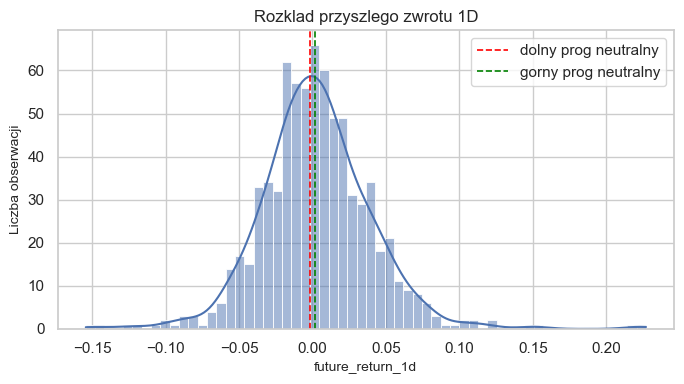

In [6]:
# Target: przyszly zwrot 1D na kolejnym dniu sesyjnym
dataset["future_return_1d"] = dataset["stock_price"].shift(-1) / dataset["stock_price"] - 1

dataset["y"] = np.select(
    [
        dataset["future_return_1d"] < -NEUTRAL_BAND,
        dataset["future_return_1d"].abs() <= NEUTRAL_BAND,
        dataset["future_return_1d"] > NEUTRAL_BAND,
    ],
    ["spadek", "bez_zmian", "wzrost"],
    default=pd.NA,
)

dataset["y_code"] = dataset["y"].map({"spadek": 0, "bez_zmian": 1, "wzrost": 2})

class_dist = (
    dataset["y"]
    .value_counts(dropna=False)
    .rename("count")
    .to_frame()
)
class_dist["pct"] = (class_dist["count"] / len(dataset) * 100).round(2)

print(f"Prog neutralny: +/- {NEUTRAL_BAND * 100:.2f}%")
display(class_dist)

plt.figure(figsize=(7, 4))
sns.histplot(dataset["future_return_1d"].dropna(), bins=60, kde=True)
plt.axvline(-NEUTRAL_BAND, color="red", linestyle="--", linewidth=1.2, label="dolny prog neutralny")
plt.axvline(NEUTRAL_BAND, color="green", linestyle="--", linewidth=1.2, label="gorny prog neutralny")
plt.title("Rozklad przyszlego zwrotu 1D")
plt.xlabel("future_return_1d")
plt.ylabel("Liczba obserwacji")
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
# Dodatkowe cechy rynku
dataset["stock_return_1d"] = dataset["stock_price"].pct_change(1)
dataset["stock_return_5d"] = dataset["stock_price"].pct_change(5)
dataset["stock_volume_change_1d"] = dataset["stock_volume"].pct_change(1)
dataset["weekday"] = dataset["date"].dt.dayofweek.astype(float)

exclude_cols = {"date", "y", "y_code", "future_return_1d"}
base_feature_cols = [c for c in dataset.columns if c not in exclude_cols]

base_dataset = dataset[["date", "y", "y_code", "future_return_1d"] + base_feature_cols].copy()
lagged_dataset = add_lag_features(base_dataset, base_feature_cols, LAG_STEPS)
lagged_dataset = lagged_dataset.dropna(subset=["y"]).reset_index(drop=True)

base_dataset.to_csv(base_output_path, index=False)
lagged_dataset.to_csv(lagged_output_path, index=False)

print(f"Zapisano bazowy dataset: {base_output_path}")
print(f"Zapisano lagged dataset: {lagged_output_path}")
print(f"Bazowy shape: {base_dataset.shape}")
print(f"Lagged shape: {lagged_dataset.shape}")
print(f"Liczba cech (z lagami): {len([c for c in lagged_dataset.columns if c not in ['date','y','y_code','future_return_1d']]):,}")


Zapisano bazowy dataset: ..\data\equity_data\model_data\stock_direction_dataset_base.csv
Zapisano lagged dataset: ..\data\equity_data\model_data\stock_direction_dataset_lagged.csv
Bazowy shape: (752, 44)
Lagged shape: (751, 244)
Liczba cech (z lagami): 240


In [8]:
# Split czasowy: ostatnie 2 miesiace jako test
test_start = (lagged_dataset["date"].max() - pd.DateOffset(months=TEST_MONTHS)).normalize()

train_df = lagged_dataset[lagged_dataset["date"] < test_start].copy()
test_df = lagged_dataset[lagged_dataset["date"] >= test_start].copy()

if train_df.empty or test_df.empty:
    raise ValueError("Split train/test jest pusty. Sprawdz zakres dat lub TEST_MONTHS.")

feature_cols = [
    c
    for c in lagged_dataset.columns
    if c not in ["date", "y", "y_code", "future_return_1d"]
]

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_train = train_df["y_code"].astype(int)
y_test = test_df["y_code"].astype(int)

print(f"Data graniczna testu: {test_start.date()}")
print(f"Train: {len(train_df):,} wierszy ({train_df['date'].min().date()} -> {train_df['date'].max().date()})")
print(f"Test:  {len(test_df):,} wierszy ({test_df['date'].min().date()} -> {test_df['date'].max().date()})")

dist_train = (train_df["y"].value_counts(normalize=True) * 100).reindex(CLASS_ORDER).fillna(0).round(2)
dist_test = (test_df["y"].value_counts(normalize=True) * 100).reindex(CLASS_ORDER).fillna(0).round(2)
display(pd.DataFrame({"train_pct": dist_train, "test_pct": dist_test}))


Data graniczna testu: 2025-10-30
Train: 709 wierszy (2023-01-03 -> 2025-10-29)
Test:  42 wierszy (2025-10-30 -> 2025-12-30)


,train_pct,test_pct
y,,
spadek,45.70,45.24
bez_zmian,5.36,7.14
wzrost,48.94,47.62


In [9]:
# Baseline i pierwsza siec neuronowa (MLP)
dummy = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyClassifier(strategy="most_frequent")),
    ]
)
dummy.fit(X_train, y_train)

mlp = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            MLPClassifier(
                hidden_layer_sizes=MLP_HIDDEN,
                activation="relu",
                alpha=MLP_ALPHA,
                learning_rate_init=1e-3,
                max_iter=MLP_MAX_ITER,
                early_stopping=True,
                n_iter_no_change=20,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
mlp.fit(X_train, y_train)

pred_dummy_test = dummy.predict(X_test)
pred_mlp_train = mlp.predict(X_train)
pred_mlp_test = mlp.predict(X_test)

def metric_row(model_name: str, split_name: str, y_true: pd.Series, y_pred: np.ndarray) -> dict:
    return {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
    }

metrics = pd.DataFrame(
    [
        metric_row("Dummy(most_frequent)", "test", y_test, pred_dummy_test),
        metric_row("MLP", "train", y_train, pred_mlp_train),
        metric_row("MLP", "test", y_test, pred_mlp_test),
    ]
)
display(metrics.round(4))

print("Raport klasyfikacji MLP (test):")
print(
    classification_report(
        y_test,
        pred_mlp_test,
        labels=CLASS_CODE_ORDER,
        target_names=CLASS_ORDER,
        zero_division=0,
    )
)


,model,split,accuracy,balanced_accuracy,macro_f1
0,Dummy(most_frequent),test,0.4762,0.3333,0.2151
1,MLP,train,0.8434,0.7034,0.7495
2,MLP,test,0.5476,0.3974,0.3639


Raport klasyfikacji MLP (test):
              precision    recall  f1-score   support

      spadek       0.52      0.84      0.64        19
   bez_zmian       0.00      0.00      0.00         3
      wzrost       0.64      0.35      0.45        20

    accuracy                           0.55        42
   macro avg       0.38      0.40      0.36        42
weighted avg       0.54      0.55      0.50        42



,pred: spadek,pred: bez_zmian,pred: wzrost
real: spadek,16,0,3
real: bez_zmian,2,0,1
real: wzrost,13,0,7


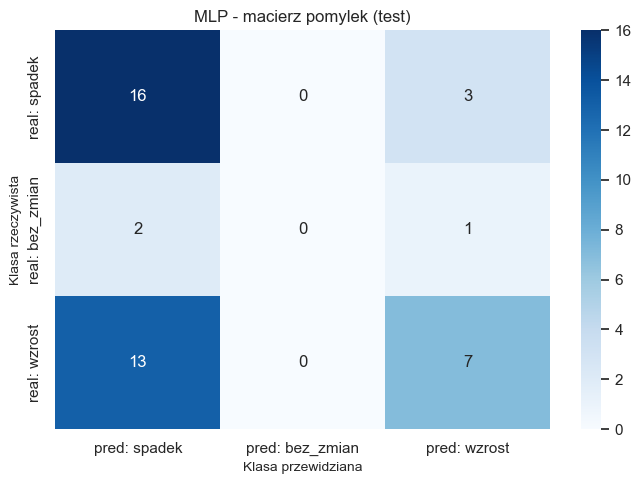

In [10]:
# Macierz pomylek dla MLP na teście
cm = confusion_matrix(y_test, pred_mlp_test, labels=CLASS_CODE_ORDER)
cm_df = pd.DataFrame(cm, index=[f"real: {c}" for c in CLASS_ORDER], columns=[f"pred: {c}" for c in CLASS_ORDER])
display(cm_df)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("MLP - macierz pomylek (test)")
plt.xlabel("Klasa przewidziana")
plt.ylabel("Klasa rzeczywista")
plt.tight_layout()
plt.show()


## Co dalej

To jest pierwszy baseline sieci neuronowej. Kolejne kroki:
- tuning progu `NEUTRAL_BAND` (wpływa na balans klas),
- tuning `LAG_STEPS` i architektury MLP,
- walidacja kroczaca (rolling / expanding window),
- porownanie z modelami drzewiastymi i prostym modelem liniowym.
